# VSD Multi-Folder DICOM Merge Pipeline

This notebook merges split lower-leg and upper-leg DICOM folders for VSD subjects 010, 015, and 017
into single NIfTI volumes ordered by physical z-position.

## Background

These three subjects were previously excluded from the knee cropping pipeline because a **lexicographic
filename bug** underestimated their lower-leg z-coverage (~59mm instead of ~450–510mm). The
`vsd_exclusion_validation.ipynb` notebook proved all three are usable after merging lower+upper B30s
folders by physical z-position (`ImagePositionPatient[2]`).

## Pipeline

1. Discover and validate multi-folder structure
2. Load both DICOM series per subject
3. Merge by physical z-position (ascending)
4. Save as NIfTI to `data/interim/merged_vsd/`
5. Validate merged volumes

## Design Decisions

| Decision | Choice | Justification |
|----------|--------|---------------|
| Kernel | B30s only | Consistent with 5 single-folder subjects already processed |
| Z-ordering | `ImagePositionPatient[2]` per-slice | Lexicographic filename ordering proven buggy |
| Output format | NIfTI (.nii.gz) | Single file per volume; consistent with existing pipeline |
| Gap tolerance | ≤ 5mm | Matches validation notebook criteria; actual gaps are 0.1–0.4mm |
| Min span | ≥ 700mm | Ensures sufficient anatomy for knee detection at 40–65% z-range |
| Output location | `data/interim/merged_vsd/` | Intermediate product; separate from raw DICOM |
| XY spacing mismatch | Resample to common grid (finest spacing) | Subject 017 has different FOV per series; resample preserves detail |
| Fill value for out-of-FOV | -1024 HU (air) | Standard CT air value; matches background outside reconstruction circle |

**Input**: Raw DICOM folders from `data/raw/VSD_Dataset/{010,015,017}/`  
**Output**: Merged NIfTI volumes in `data/interim/merged_vsd/`

## 1 — Imports & Configuration

In [1]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# ============================================================
# Paths
# ============================================================
PROJECT_ROOT = Path(r"C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject")
VSD_ROOT = PROJECT_ROOT / "data" / "raw" / "VSD_Dataset"
OUTPUT_DIR = PROJECT_ROOT / "data" / "interim" / "merged_vsd"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Multi-folder subject mapping: subject_id -> (lower_smir_id, upper_smir_id)
# B30s kernel selected for consistency with single-folder subjects
# ============================================================
MERGE_SUBJECTS = {
    "010": {"lower": "268", "upper": "265"},
    "015": {"lower": "453", "upper": "455"},
    "016": {"lower": "481", "upper": "476"},
    "017": {"lower": "490", "upper": "487"},
    "019": {"lower": "497", "upper": "495"},
}

# ============================================================
# Validation thresholds (from vsd_exclusion_validation.ipynb)
# ============================================================
MAX_GAP_MM = 5.0
MIN_MERGED_SPAN_MM = 700

# Resampling
RESAMPLE_FILL_HU = -1024  # Air HU for out-of-FOV regions after XY resampling

# Bone profile parameters (for post-merge validation)
BONE_HU_THRESHOLD = 200
KNEE_Z_RANGE = (0.40, 0.65)

print(f"VSD root  : {VSD_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Subjects  : {list(MERGE_SUBJECTS.keys())}")
print(f"Thresholds: gap <= {MAX_GAP_MM}mm, span >= {MIN_MERGED_SPAN_MM}mm")

VSD root  : C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\raw\VSD_Dataset
Output dir: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\merged_vsd
Subjects  : ['010', '015', '016', '017', '019']
Thresholds: gap <= 5.0mm, span >= 700mm


## 2 — Helper Functions

In [2]:
def get_series_dir(subject_id, smir_id):
    """Resolve the DICOM series directory for a given subject and SMIR ID."""
    subject_dir = VSD_ROOT / subject_id
    matches = [d for d in subject_dir.iterdir() if d.is_dir() and d.name.endswith(f".{smir_id}")]
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Expected exactly 1 folder ending with '.{smir_id}' in {subject_dir}, "
            f"found {len(matches)}: {[m.name for m in matches]}"
        )
    return matches[0]


def read_all_z_positions(series_dir):
    """Read ImagePositionPatient[2] from every DICOM file. Returns sorted z array."""
    dcm_files = sorted(series_dir.glob("*.dcm"))
    if not dcm_files:
        raise FileNotFoundError(f"No .dcm files in {series_dir}")

    z_positions = np.array([
        float(pydicom.dcmread(str(f), stop_before_pixels=True).ImagePositionPatient[2])
        for f in dcm_files
    ])
    return z_positions


def load_series_volume(series_dir):
    """
    Load a DICOM series as SimpleITK image and extract per-slice z-positions.

    Returns: (sitk_image, z_positions_array)
    """
    reader = sitk.ImageSeriesReader()
    dicom_names = list(reader.GetGDCMSeriesFileNames(str(series_dir)))
    if not dicom_names:
        raise FileNotFoundError(f"SimpleITK found no DICOM series in {series_dir}")

    reader.SetFileNames(dicom_names)
    img = reader.Execute()

    z_positions = np.array([
        float(pydicom.dcmread(str(f), stop_before_pixels=True).ImagePositionPatient[2])
        for f in dicom_names
    ])

    return img, z_positions


def needs_xy_resampling(img_lower, img_upper, tol=1e-4):
    """Check if two volumes need XY resampling before merging."""
    sp_lower = img_lower.GetSpacing()
    sp_upper = img_upper.GetSpacing()
    sz_lower = img_lower.GetSize()
    sz_upper = img_upper.GetSize()
    or_lower = img_lower.GetOrigin()
    or_upper = img_upper.GetOrigin()

    spacing_match = (abs(sp_lower[0] - sp_upper[0]) < tol and
                     abs(sp_lower[1] - sp_upper[1]) < tol)
    size_match = (sz_lower[0] == sz_upper[0] and sz_lower[1] == sz_upper[1])
    origin_match = (abs(or_lower[0] - or_upper[0]) < tol and
                    abs(or_lower[1] - or_upper[1]) < tol)

    return not (spacing_match and size_match and origin_match)


def compute_common_reference_grid(img_lower, img_upper):
    """Compute a common XY grid encompassing both FOVs at the finest spacing."""
    sp_lower = img_lower.GetSpacing()
    sp_upper = img_upper.GetSpacing()
    or_lower = img_lower.GetOrigin()
    or_upper = img_upper.GetOrigin()
    sz_lower = img_lower.GetSize()
    sz_upper = img_upper.GetSize()

    common_sp_x = min(sp_lower[0], sp_upper[0])
    common_sp_y = min(sp_lower[1], sp_upper[1])

    x_min = min(or_lower[0], or_upper[0])
    x_max = max(or_lower[0] + sz_lower[0] * sp_lower[0],
                or_upper[0] + sz_upper[0] * sp_upper[0])
    y_min = min(or_lower[1], or_upper[1])
    y_max = max(or_lower[1] + sz_lower[1] * sp_lower[1],
                or_upper[1] + sz_upper[1] * sp_upper[1])

    out_size_x = int(np.ceil((x_max - x_min) / common_sp_x))
    out_size_y = int(np.ceil((y_max - y_min) / common_sp_y))

    return (x_min, y_min), (out_size_x, out_size_y), (common_sp_x, common_sp_y)


def resample_volume_to_common_grid(img, common_origin_xy, common_size_xy, common_spacing_xy,
                                    fill_value=RESAMPLE_FILL_HU):
    """Resample a 3D volume so its XY grid matches the common reference, keeping Z unchanged."""
    original_spacing = img.GetSpacing()
    original_origin = img.GetOrigin()
    original_size = img.GetSize()

    out_spacing = (common_spacing_xy[0], common_spacing_xy[1], original_spacing[2])
    out_size = (common_size_xy[0], common_size_xy[1], original_size[2])
    out_origin = (common_origin_xy[0], common_origin_xy[1], original_origin[2])

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(out_spacing)
    resampler.SetSize(out_size)
    resampler.SetOutputOrigin(out_origin)
    resampler.SetOutputDirection(img.GetDirection())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(fill_value)
    resampler.SetInterpolator(sitk.sitkLinear)

    return resampler.Execute(img)


def validate_merge_compatibility(img_lower, img_upper, z_lower, z_upper, subject_id):
    """
    Validate that two volumes can be merged:
    - Check XY spacing/size compatibility (log warning if mismatch, flag for resampling)
    - Gap between lower max-z and upper min-z <= MAX_GAP_MM
    - Combined span >= MIN_MERGED_SPAN_MM
    """
    sp_lower = img_lower.GetSpacing()
    sp_upper = img_upper.GetSpacing()
    sz_lower = img_lower.GetSize()
    sz_upper = img_upper.GetSize()

    resample_needed = needs_xy_resampling(img_lower, img_upper)

    if resample_needed:
        print(f"    XY mismatch detected — will resample to common grid")
        print(f"      Lower: spacing=({sp_lower[0]:.6f}, {sp_lower[1]:.6f}), size={sz_lower[:2]}")
        print(f"      Upper: spacing=({sp_upper[0]:.6f}, {sp_upper[1]:.6f}), size={sz_upper[:2]}")
    else:
        print(f"    XY spacing/size match — no resampling needed")

    # Gap check
    gap = float(z_upper.min() - z_lower.max())
    assert gap <= MAX_GAP_MM, (
        f"{subject_id}: Gap {gap:.2f}mm exceeds threshold {MAX_GAP_MM}mm"
    )

    # Span check
    merged_span = float(z_upper.max() - z_lower.min())
    assert merged_span >= MIN_MERGED_SPAN_MM, (
        f"{subject_id}: Merged span {merged_span:.1f}mm < minimum {MIN_MERGED_SPAN_MM}mm"
    )

    return {"gap_mm": gap, "merged_span_mm": merged_span, "needs_resample": resample_needed}


print("Helper functions defined.")

Helper functions defined.


## 3 — Discover & Validate Folder Structure

Confirm both B30s folders exist for each subject and validate z-coverage
**without loading pixel data** (reads only DICOM headers).

In [3]:
discovery_rows = []

for subject_id, folder_ids in MERGE_SUBJECTS.items():
    for region, smir_id in folder_ids.items():
        series_dir = get_series_dir(subject_id, smir_id)
        z_positions = read_all_z_positions(series_dir)

        discovery_rows.append({
            "subject": subject_id,
            "region": region,
            "smir_id": smir_id,
            "folder": series_dir.name,
            "n_slices": len(z_positions),
            "z_min_mm": round(float(z_positions.min()), 1),
            "z_max_mm": round(float(z_positions.max()), 1),
            "z_span_mm": round(float(z_positions.max() - z_positions.min()), 1),
        })
        print(f"  {subject_id}/{region} (ID {smir_id}): {len(z_positions)} slices, "
              f"z=[{z_positions.min():.1f}, {z_positions.max():.1f}]mm")

df_discovery = pd.DataFrame(discovery_rows)
display(df_discovery)

# Validate gap and span for each subject
print("\n--- Merge Feasibility ---")
for subject_id in MERGE_SUBJECTS:
    sub = df_discovery[df_discovery["subject"] == subject_id]
    lower = sub[sub["region"] == "lower"].iloc[0]
    upper = sub[sub["region"] == "upper"].iloc[0]

    gap = upper["z_min_mm"] - lower["z_max_mm"]
    merged_span = upper["z_max_mm"] - lower["z_min_mm"]

    gap_ok = gap <= MAX_GAP_MM
    span_ok = merged_span >= MIN_MERGED_SPAN_MM

    status = "✅ PASS" if (gap_ok and span_ok) else "❌ FAIL"
    print(f"  {subject_id}: gap={gap:.2f}mm ({'OK' if gap_ok else 'FAIL'}), "
          f"span={merged_span:.1f}mm ({'OK' if span_ok else 'FAIL'}) {status}")

    assert gap_ok and span_ok, f"Subject {subject_id} fails validation"

  010/lower (ID 268): 763 slices, z=[238.8, 696.0]mm
  010/upper (ID 265): 997 slices, z=[696.4, 1294.0]mm
  015/lower (ID 453): 831 slices, z=[-94.5, 403.5]mm
  015/upper (ID 455): 1074 slices, z=[403.7, 1047.5]mm
  016/lower (ID 481): 722 slices, z=[33.9, 466.5]mm
  016/upper (ID 476): 1056 slices, z=[467.0, 1100.0]mm
  017/lower (ID 490): 849 slices, z=[-39.3, 469.5]mm
  017/upper (ID 487): 1020 slices, z=[469.6, 1081.0]mm
  019/lower (ID 497): 844 slices, z=[-113.3, 392.5]mm
  019/upper (ID 495): 1051 slices, z=[393.0, 1023.0]mm


,subject,region,smir_id,folder,n_slices,z_min_mm,z_max_mm,z_span_mm
0,010,lower,268,SMIR.Lower_limb.045Y.F.CT.268,763,238.8,696.0,457.2
1,010,upper,265,SMIR.Lower_limb.045Y.F.CT.265,997,696.4,1294.0,597.6
2,015,lower,453,SMIR.Lower_limb.081Y.M.CT.453,831,-94.5,403.5,498.0
3,015,upper,455,SMIR.Lower_limb.081Y.M.CT.455,1074,403.7,1047.5,643.8
4,016,lower,481,SMIR.Lower_limb.095Y.F.CT.481,722,33.9,466.5,432.6
5,016,upper,476,SMIR.Lower_limb.095Y.F.CT.476,1056,467.0,1100.0,633.0
6,017,lower,490,SMIR.Lower_limb.019Y.F.CT.490,849,-39.3,469.5,508.8
7,017,upper,487,SMIR.Lower_limb.019Y.F.CT.487,1020,469.6,1081.0,611.4
8,019,lower,497,SMIR.Lower_limb.056Y.M.CT.497,844,-113.3,392.5,505.8
9,019,upper,495,SMIR.Lower_limb.056Y.M.CT.495,1051,393.0,1023.0,630.0



--- Merge Feasibility ---
  010: gap=0.40mm (OK), span=1055.2mm (OK) ✅ PASS
  015: gap=0.20mm (OK), span=1142.0mm (OK) ✅ PASS
  016: gap=0.50mm (OK), span=1066.1mm (OK) ✅ PASS
  017: gap=0.10mm (OK), span=1120.3mm (OK) ✅ PASS
  019: gap=0.50mm (OK), span=1136.3mm (OK) ✅ PASS


## 4 — Merge Volumes

For each subject:
1. Load both DICOM series (lower + upper B30s)
2. Extract per-slice z-positions
3. Validate spacing/dimension compatibility
4. Concatenate arrays sorted by physical z-position
5. Construct SimpleITK image with correct metadata
6. Save as NIfTI

In [4]:
merge_metadata = []

for subject_id, folder_ids in MERGE_SUBJECTS.items():
    print(f"\n{'='*60}")
    print(f"Processing subject {subject_id}...")
    print(f"{'='*60}")

    # Load both series
    lower_dir = get_series_dir(subject_id, folder_ids["lower"])
    upper_dir = get_series_dir(subject_id, folder_ids["upper"])

    print(f"  Loading lower (ID {folder_ids['lower']})...")
    img_lower, z_lower = load_series_volume(lower_dir)
    print(f"    {img_lower.GetSize()}, z=[{z_lower.min():.1f}, {z_lower.max():.1f}]mm")

    print(f"  Loading upper (ID {folder_ids['upper']})...")
    img_upper, z_upper = load_series_volume(upper_dir)
    print(f"    {img_upper.GetSize()}, z=[{z_upper.min():.1f}, {z_upper.max():.1f}]mm")

    # Validate compatibility
    print(f"  Validating compatibility...")
    val_result = validate_merge_compatibility(img_lower, img_upper, z_lower, z_upper, subject_id)
    print(f"    Gap: {val_result['gap_mm']:.2f}mm, Merged span: {val_result['merged_span_mm']:.1f}mm")

    # XY resampling if needed (e.g., Subject 017 has different FOV per series)
    if val_result["needs_resample"]:
        print(f"  Resampling to common XY grid...")
        common_origin_xy, common_size_xy, common_spacing_xy = compute_common_reference_grid(
            img_lower, img_upper
        )
        print(f"    Common grid: origin=({common_origin_xy[0]:.2f}, {common_origin_xy[1]:.2f}), "
              f"size={common_size_xy}, spacing=({common_spacing_xy[0]:.6f}, {common_spacing_xy[1]:.6f})")

        img_lower = resample_volume_to_common_grid(
            img_lower, common_origin_xy, common_size_xy, common_spacing_xy
        )
        img_upper = resample_volume_to_common_grid(
            img_upper, common_origin_xy, common_size_xy, common_spacing_xy
        )
        print(f"    Lower resampled: {img_lower.GetSize()}, spacing={tuple(round(s,6) for s in img_lower.GetSpacing())}")
        print(f"    Upper resampled: {img_upper.GetSize()}, spacing={tuple(round(s,6) for s in img_upper.GetSpacing())}")

    # Convert to arrays
    arr_lower = sitk.GetArrayFromImage(img_lower)  # shape: (z, y, x)
    arr_upper = sitk.GetArrayFromImage(img_upper)

    # Concatenate z-positions and arrays
    z_all = np.concatenate([z_lower, z_upper])
    arr_all = np.concatenate([arr_lower, arr_upper], axis=0)

    # Sort by physical z-position (ascending)
    sort_order = np.argsort(z_all)
    z_sorted = z_all[sort_order]
    arr_sorted = arr_all[sort_order]

    print(f"  Merged: {arr_sorted.shape}, z=[{z_sorted[0]:.1f}, {z_sorted[-1]:.1f}]mm")

    # Construct SimpleITK image
    spacing = img_lower.GetSpacing()  # (x, y, z) - validated identical
    direction = img_lower.GetDirection()

    # Origin: use the physical position of the first (lowest-z) slice
    origin_lower = img_lower.GetOrigin()
    origin_upper = img_upper.GetOrigin()

    # The origin x,y come from the volume; z comes from the lowest slice
    # Determine which volume contains the lowest-z slice
    if z_lower.min() <= z_upper.min():
        merged_origin = (origin_lower[0], origin_lower[1], float(z_sorted[0]))
    else:
        merged_origin = (origin_upper[0], origin_upper[1], float(z_sorted[0]))

    merged_img = sitk.GetImageFromArray(arr_sorted)
    merged_img.SetSpacing(spacing)
    merged_img.SetOrigin(merged_origin)
    merged_img.SetDirection(direction)

    # Save
    out_name = f"VSD_{subject_id}_merged.nii.gz"
    out_path = OUTPUT_DIR / out_name
    sitk.WriteImage(merged_img, str(out_path))
    file_size = out_path.stat().st_size

    print(f"  ✅ Saved: {out_path.name} ({file_size / 1e6:.1f} MB)")

    # Record metadata
    merge_metadata.append({
        "subject_id": subject_id,
        "lower_folder": lower_dir.name,
        "upper_folder": upper_dir.name,
        "lower_smir_id": folder_ids["lower"],
        "upper_smir_id": folder_ids["upper"],
        "n_slices_lower": len(z_lower),
        "n_slices_upper": len(z_upper),
        "n_slices_merged": len(z_sorted),
        "gap_mm": round(val_result["gap_mm"], 2),
        "merged_z_min_mm": round(float(z_sorted[0]), 1),
        "merged_z_max_mm": round(float(z_sorted[-1]), 1),
        "merged_span_mm": round(val_result["merged_span_mm"], 1),
        "xy_resampled": val_result["needs_resample"],
        "spacing_xyz_mm": f"({spacing[0]:.4f}, {spacing[1]:.4f}, {spacing[2]:.4f})",
        "merged_shape_zyx": str(arr_sorted.shape),
        "output_file": out_name,
        "output_size_mb": round(file_size / 1e6, 1),
    })

    # Free memory
    del img_lower, img_upper, arr_lower, arr_upper, arr_all, arr_sorted, merged_img
    gc.collect()

print(f"\n{'='*60}")
print(f"Done. {len(merge_metadata)} merged volumes saved to {OUTPUT_DIR}")


Processing subject 010...
  Loading lower (ID 268)...
    (512, 512, 763), z=[238.8, 696.0]mm
  Loading upper (ID 265)...
    (512, 512, 997), z=[696.4, 1294.0]mm
  Validating compatibility...
    XY spacing/size match — no resampling needed
    Gap: 0.40mm, Merged span: 1055.2mm
  Merged: (1760, 512, 512), z=[238.8, 1294.0]mm
  ✅ Saved: VSD_010_merged.nii.gz (385.7 MB)

Processing subject 015...
  Loading lower (ID 453)...
    (512, 512, 831), z=[-94.5, 403.5]mm
  Loading upper (ID 455)...
    (512, 512, 1074), z=[403.7, 1047.5]mm
  Validating compatibility...
    XY spacing/size match — no resampling needed
    Gap: 0.20mm, Merged span: 1142.0mm
  Merged: (1905, 512, 512), z=[-94.5, 1047.5]mm
  ✅ Saved: VSD_015_merged.nii.gz (435.0 MB)

Processing subject 016...
  Loading lower (ID 481)...
    (512, 512, 722), z=[33.9, 466.5]mm
  Loading upper (ID 476)...
    (512, 512, 1056), z=[467.0, 1100.0]mm
  Validating compatibility...
    XY mismatch detected — will resample to common grid
 

## 5 — Post-Merge Validation

Reload each saved NIfTI and verify:
- Shape, spacing, and z-extent match expectations
- HU range is reasonable for CT
- Bone cross-section profile detects knee peak at ~48–49%
- 3-plane views show continuous anatomy

In [8]:
saved_files = sorted(OUTPUT_DIR.glob("VSD_*_merged.nii.gz"))
print(f"Validating {len(saved_files)} merged volumes...\n")

val_records = []
for fpath in saved_files:
    vol = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(vol)
    sp = vol.GetSpacing()
    origin = vol.GetOrigin()

    z_extent = arr.shape[0] * sp[2]
    val_records.append({
        "file": fpath.name,
        "shape (z,y,x)": arr.shape,
        "spacing (x,y,z)": tuple(round(s, 4) for s in sp),
        "origin_z": round(origin[2], 1),
        "z_extent_mm": round(z_extent, 1),
        "HU_min": int(arr.min()),
        "HU_max": int(arr.max()),
    })
    print(f"  ✅ {fpath.name}: shape={arr.shape}, z_extent={z_extent:.1f}mm, "
          f"HU=[{arr.min()}, {arr.max()}]")
    del arr
    gc.collect()

display(pd.DataFrame(val_records))

# Cross-check against expected merged spans from validation notebook
expected_spans = {"010": 1055.2, "015": 1142.0, "016": 1066.1, "017": 1120.3, "019":1136.3}
print("\n--- Span Cross-Check ---")
for rec in val_records:
    subject_id = rec["file"].split("_")[1]
    expected = expected_spans[subject_id]
    actual = rec["z_extent_mm"]
    diff = abs(actual - expected)
    status = "✅" if diff < 5.0 else "⚠️"
    print(f"  {subject_id}: expected ~{expected}mm, got {actual}mm (diff={diff:.1f}mm) {status}")

Validating 5 merged volumes...

  ✅ VSD_010_merged.nii.gz: shape=(1760, 512, 512), z_extent=1056.0mm, HU=[-1024, 2015]
  ✅ VSD_015_merged.nii.gz: shape=(1905, 512, 512), z_extent=1143.0mm, HU=[-1024, 3071]
  ✅ VSD_016_merged.nii.gz: shape=(1778, 593, 593), z_extent=1066.8mm, HU=[-1024, 3071]
  ✅ VSD_017_merged.nii.gz: shape=(1869, 703, 703), z_extent=1121.4mm, HU=[-1024, 3070]
  ✅ VSD_019_merged.nii.gz: shape=(1895, 582, 549), z_extent=1137.0mm, HU=[-1024, 3071]


,file,"shape (z,y,x)","spacing (x,y,z)",origin_z,z_extent_mm,HU_min,HU_max
0,VSD_010_merged.nii.gz,"(1760, 512, 512)","(0.8262, 0.8262, 0.6)",238.8,1056.0,-1024,2015
1,VSD_015_merged.nii.gz,"(1905, 512, 512)","(0.7656, 0.7656, 0.6)",-94.5,1143.0,-1024,3071
2,VSD_016_merged.nii.gz,"(1778, 593, 593)","(0.7539, 0.7539, 0.6)",33.9,1066.8,-1024,3071
3,VSD_017_merged.nii.gz,"(1869, 703, 703)","(0.5195, 0.5195, 0.6)",-39.3,1121.4,-1024,3070
4,VSD_019_merged.nii.gz,"(1895, 582, 549)","(0.6523, 0.6523, 0.6)",-113.3,1137.0,-1024,3071



--- Span Cross-Check ---
  010: expected ~1055.2mm, got 1056.0mm (diff=0.8mm) ✅
  015: expected ~1142.0mm, got 1143.0mm (diff=1.0mm) ✅
  016: expected ~1066.1mm, got 1066.8mm (diff=0.7mm) ✅
  017: expected ~1120.3mm, got 1121.4mm (diff=1.1mm) ✅
  019: expected ~1136.3mm, got 1137.0mm (diff=0.7mm) ✅


C:\Users\Chan Zheng Shao\AppData\Local\Temp\ipykernel_35412\222666911.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


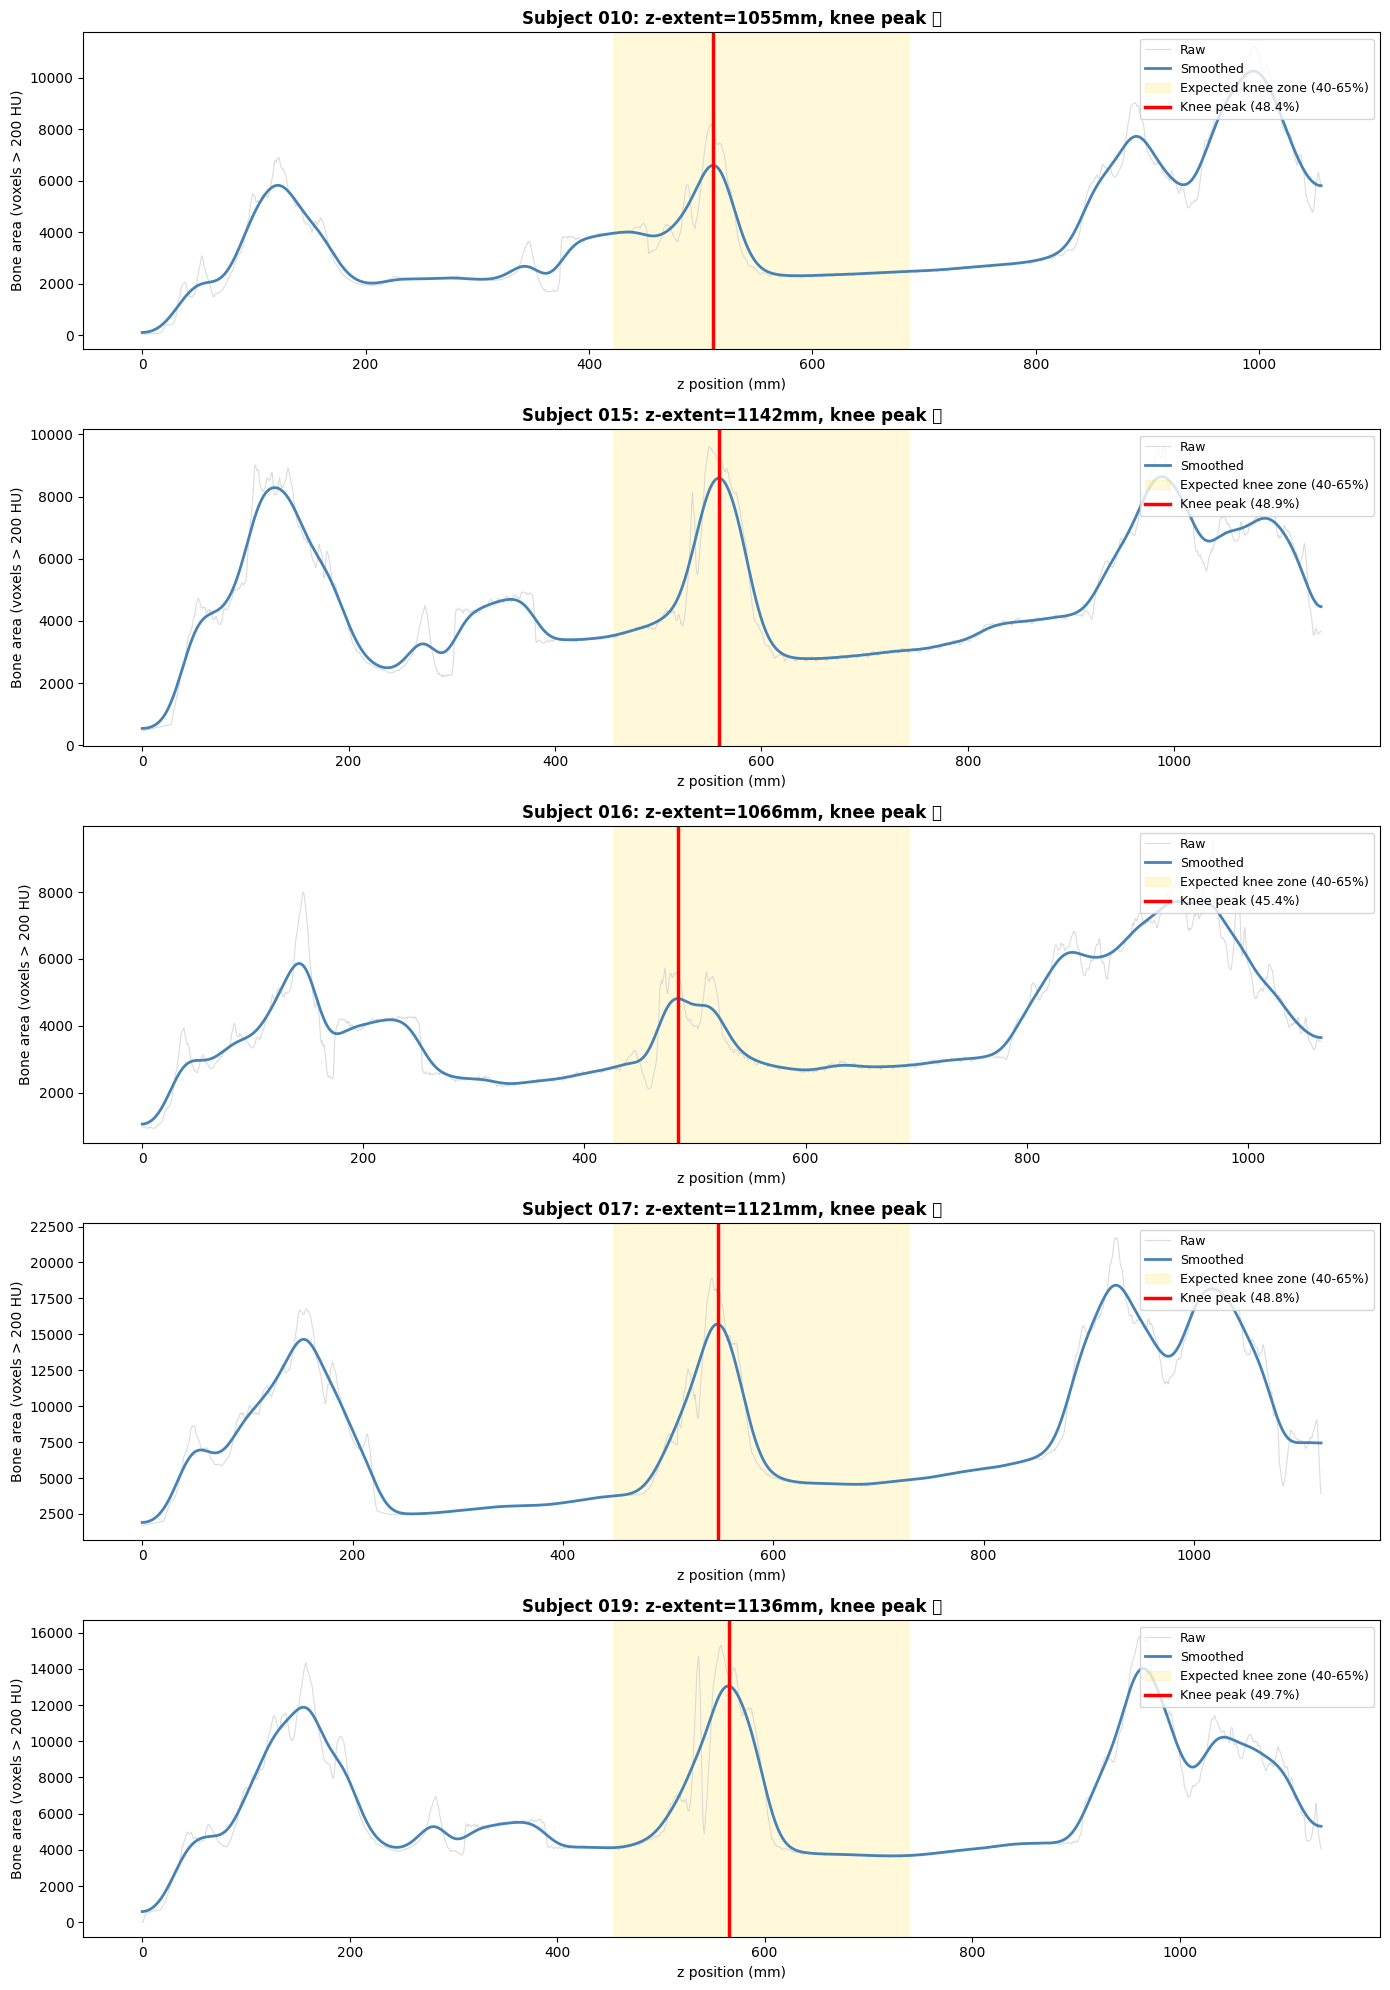

In [6]:
# Bone cross-section profile validation
fig, axes = plt.subplots(len(saved_files), 1, figsize=(14, 4 * len(saved_files)))
if len(saved_files) == 1:
    axes = [axes]

for ax, fpath in zip(axes, saved_files):
    subject_id = fpath.name.split("_")[1]
    vol = sitk.ReadImage(str(fpath))
    arr = sitk.GetArrayFromImage(vol)
    sp = vol.GetSpacing()

    # Bone area profile
    bone_area = (arr > BONE_HU_THRESHOLD).sum(axis=(1, 2)).astype(float)
    z_mm = np.arange(arr.shape[0]) * sp[2]
    smoothed = gaussian_filter1d(bone_area, sigma=20)

    # Knee peak detection
    peaks, _ = find_peaks(
        smoothed,
        height=smoothed.max() * 0.20,
        distance=80,
        prominence=smoothed.max() * 0.05,
    )

    total_z = z_mm[-1]
    knee_low = total_z * KNEE_Z_RANGE[0]
    knee_high = total_z * KNEE_Z_RANGE[1]
    knee_candidates = [p for p in peaks if knee_low <= z_mm[p] <= knee_high]
    best_peak = max(knee_candidates, key=lambda p: smoothed[p]) if knee_candidates else None

    # Plot
    ax.plot(z_mm, bone_area, color="lightgray", linewidth=0.8, alpha=0.8, label="Raw")
    ax.plot(z_mm, smoothed, color="steelblue", linewidth=2, label="Smoothed")
    ax.axvspan(knee_low, knee_high, color="gold", alpha=0.15, label="Expected knee zone (40-65%)")

    if best_peak is not None:
        knee_pct = z_mm[best_peak] / total_z * 100
        ax.axvline(z_mm[best_peak], color="red", linewidth=2.5,
                   label=f"Knee peak ({knee_pct:.1f}%)")
        status = "✅"
    else:
        status = "❌ NO PEAK"

    ax.set_title(f"Subject {subject_id}: z-extent={total_z:.0f}mm, knee peak {status}",
                 fontweight="bold")
    ax.set_xlabel("z position (mm)")
    ax.set_ylabel("Bone area (voxels > 200 HU)")
    ax.legend(loc="upper right", fontsize=9)

    del arr
    gc.collect()

plt.tight_layout()
plt.show()

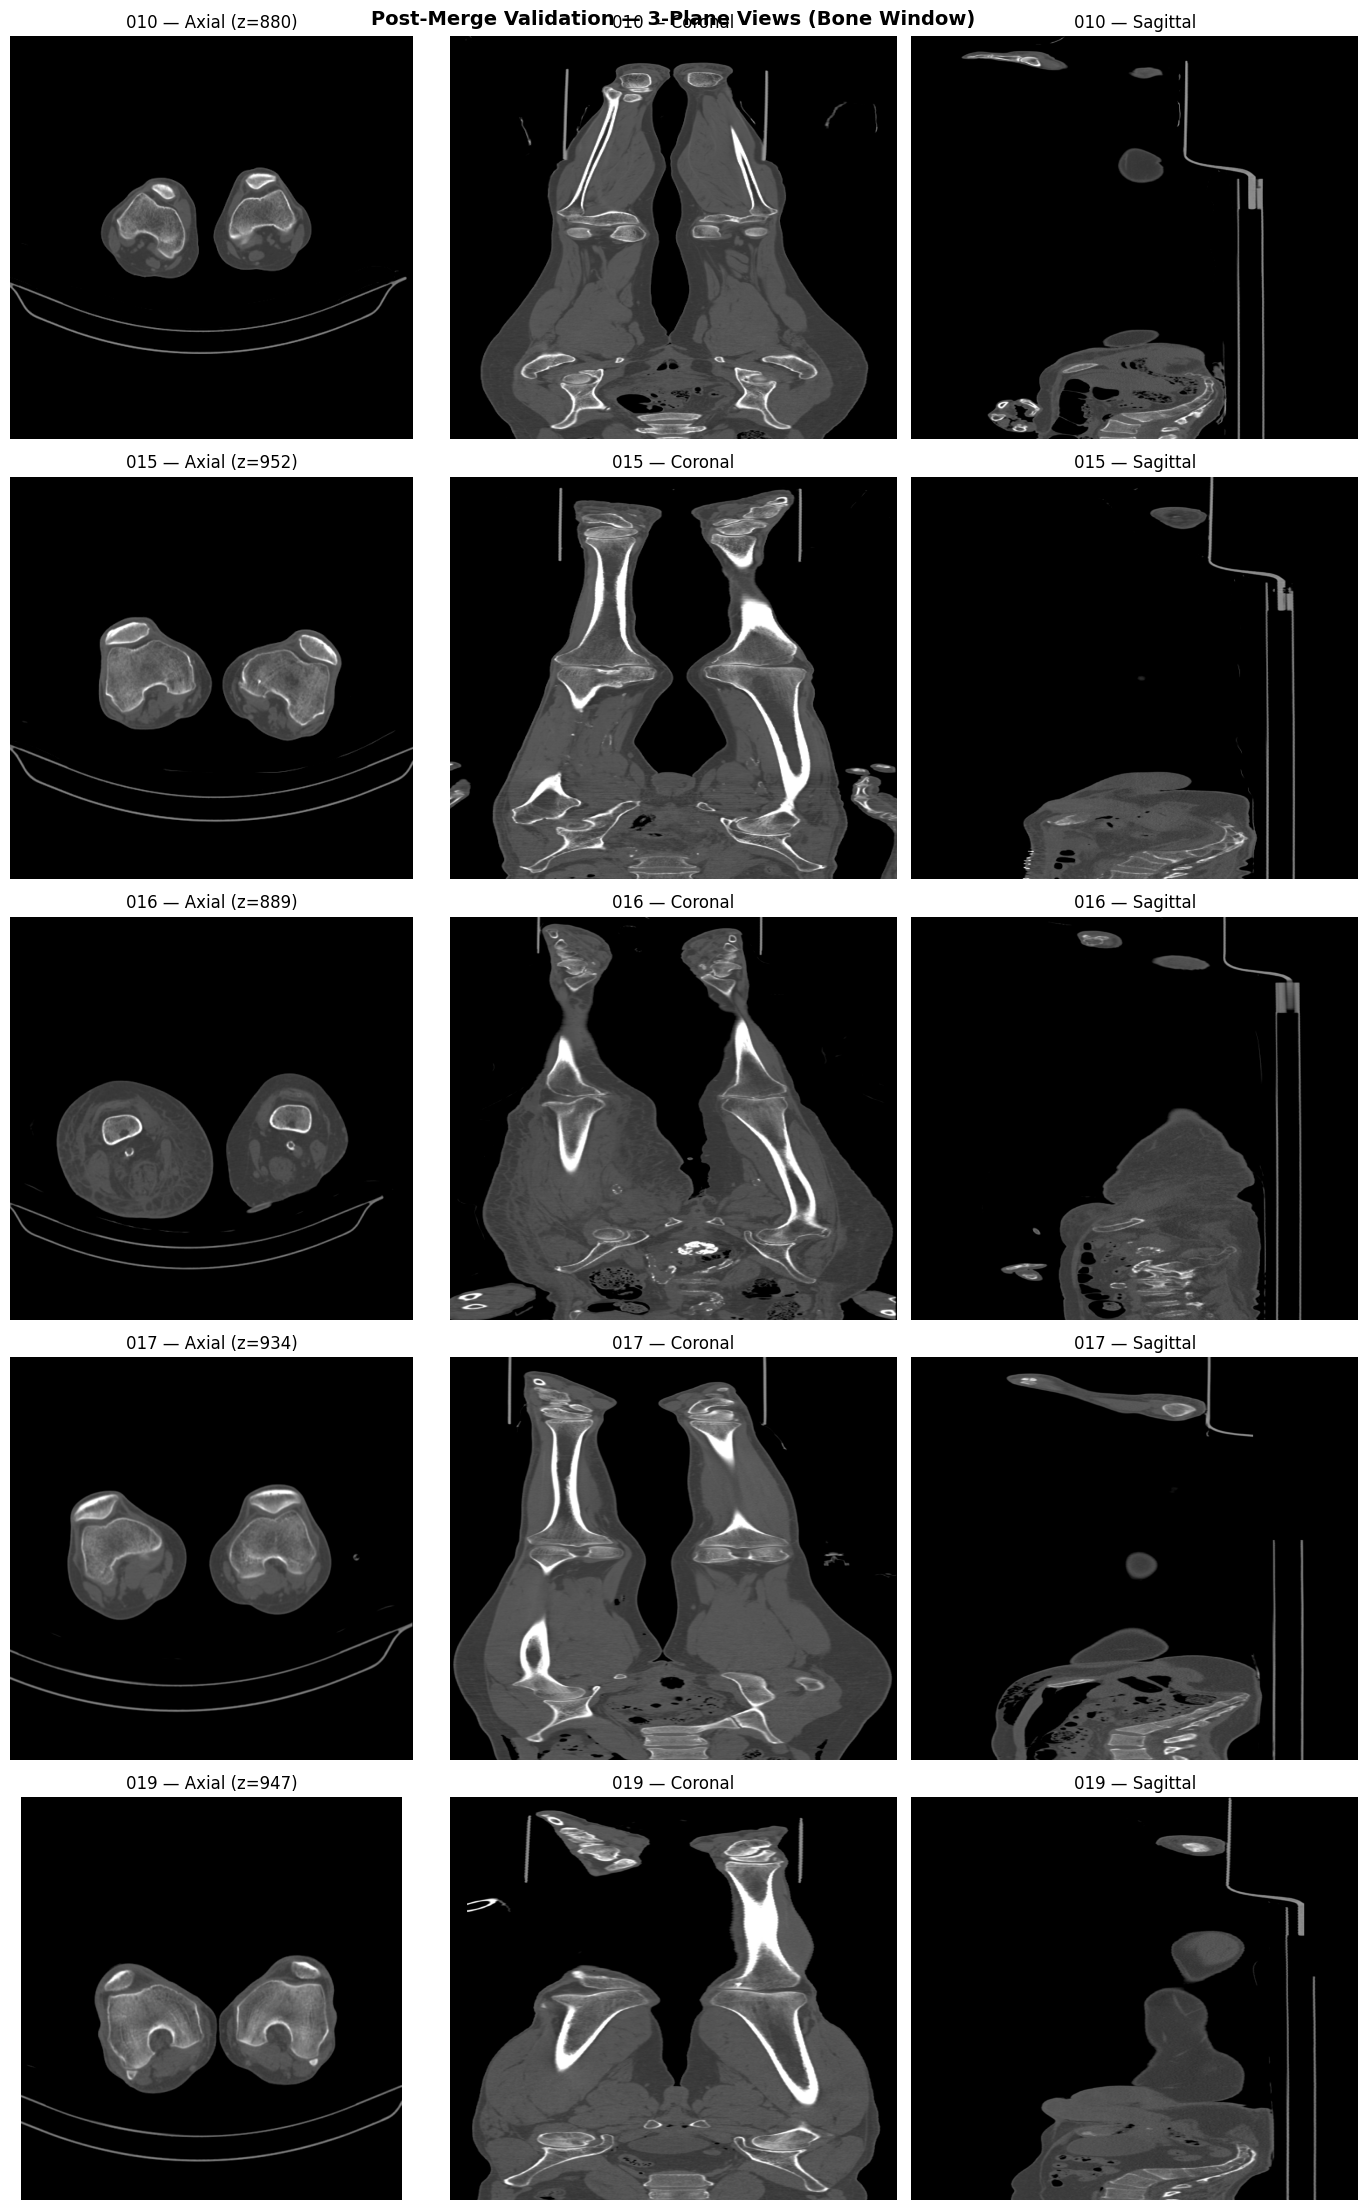

In [7]:
# 3-plane visualization
fig, axes = plt.subplots(len(saved_files), 3, figsize=(14, 4.5 * len(saved_files)))
if len(saved_files) == 1:
    axes = axes[np.newaxis, :]

HU_WINDOW = (-450, 1050)

for i, fpath in enumerate(saved_files):
    subject_id = fpath.name.split("_")[1]
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(fpath)))
    mid = [s // 2 for s in arr.shape]

    axes[i, 0].imshow(arr[mid[0]], cmap="gray", vmin=HU_WINDOW[0], vmax=HU_WINDOW[1])
    axes[i, 0].set_title(f"{subject_id} — Axial (z={mid[0]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(arr[:, mid[1], :], cmap="gray", vmin=HU_WINDOW[0], vmax=HU_WINDOW[1],
                      aspect="auto")
    axes[i, 1].set_title(f"{subject_id} — Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(arr[:, :, mid[2]], cmap="gray", vmin=HU_WINDOW[0], vmax=HU_WINDOW[1],
                      aspect="auto")
    axes[i, 2].set_title(f"{subject_id} — Sagittal")
    axes[i, 2].axis("off")

    del arr
    gc.collect()

plt.suptitle("Post-Merge Validation — 3-Plane Views (Bone Window)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Metadata & Summary

In [9]:
# Save metadata CSV
df_meta = pd.DataFrame(merge_metadata)
meta_path = OUTPUT_DIR / "merge_metadata.csv"
df_meta.to_csv(meta_path, index=False)

print("Merge metadata:")
display(df_meta)
print(f"\nMetadata saved to: {meta_path}")

print("\n" + "=" * 60)
print("PIPELINE COMPLETE")
print("=" * 60)
print(f"\nMerged {len(merge_metadata)} multi-folder VSD subjects:")
for row in merge_metadata:
    print(f"  {row['subject_id']}: {row['n_slices_lower']} + {row['n_slices_upper']} "
          f"= {row['n_slices_merged']} slices, span={row['merged_span_mm']}mm")

print(f"\nOutput directory: {OUTPUT_DIR}")

Merge metadata:


,subject_id,lower_folder,upper_folder,lower_smir_id,upper_smir_id,n_slices_lower,n_slices_upper,n_slices_merged,gap_mm,merged_z_min_mm,merged_z_max_mm,merged_span_mm,xy_resampled,spacing_xyz_mm,merged_shape_zyx,output_file,output_size_mb
0,010,SMIR.Lower_limb.045Y.F.CT.268,SMIR.Lower_limb.045Y.F.CT.265,268,265,763,997,1760,0.4,238.8,1294.0,1055.2,False,"(0.8262, 0.8262, 0.6000)","(1760, 512, 512)",VSD_010_merged.nii.gz,385.7
1,015,SMIR.Lower_limb.081Y.M.CT.453,SMIR.Lower_limb.081Y.M.CT.455,453,455,831,1074,1905,0.2,-94.5,1047.5,1142.0,False,"(0.7656, 0.7656, 0.6000)","(1905, 512, 512)",VSD_015_merged.nii.gz,435.0
2,016,SMIR.Lower_limb.095Y.F.CT.481,SMIR.Lower_limb.095Y.F.CT.476,481,476,722,1056,1778,0.5,33.9,1100.0,1066.1,True,"(0.7539, 0.7539, 0.6000)","(1778, 593, 593)",VSD_016_merged.nii.gz,503.8
3,017,SMIR.Lower_limb.019Y.F.CT.490,SMIR.Lower_limb.019Y.F.CT.487,490,487,849,1020,1869,0.1,-39.3,1081.0,1120.3,True,"(0.5195, 0.5195, 0.6000)","(1869, 703, 703)",VSD_017_merged.nii.gz,698.8
4,019,SMIR.Lower_limb.056Y.M.CT.497,SMIR.Lower_limb.056Y.M.CT.495,497,495,844,1051,1895,0.5,-113.3,1023.0,1136.3,True,"(0.6523, 0.6523, 0.6000)","(1895, 582, 549)",VSD_019_merged.nii.gz,525.7



Metadata saved to: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\merged_vsd\merge_metadata.csv

PIPELINE COMPLETE

Merged 5 multi-folder VSD subjects:
  010: 763 + 997 = 1760 slices, span=1055.2mm
  015: 831 + 1074 = 1905 slices, span=1142.0mm
  016: 722 + 1056 = 1778 slices, span=1066.1mm
  017: 849 + 1020 = 1869 slices, span=1120.3mm
  019: 844 + 1051 = 1895 slices, span=1136.3mm

Output directory: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\data\interim\merged_vsd
